# Diskrete Fourier-Transformation
Die diskrete Fourier-Transformation (DFT) wird ausführlich im Buch <cite>DAFX: Digital Audio Effects (second edition)</cite> in Kapitel 1.3.2 - Spektralanalyse digitaler Signale beschrieben.

Die DFT eines zeitdiskreten Signals $x(n)$ wird über einen Block mit $N$ Abtastwerten mit der folgenden Gleichung berechnet:

$X(k)=\sum_{n=0}^{N-1} x(n)\cdot e^{-j2\pi nk/K}, 0\leq n<N, K \geq N$

Zur Vereinfachung nehmen wir zunächst an, dass die Blocklänge $N$ gleich der Transformationslänge $K$ ist: $N=K$. Das entspricht dem Fall ohne Zero Padding.

Der inverse Algorithmus ist die IDFT (inverse diskrete Fourier-Transformation):

$x(n) = \frac{1}{K}\sum_{k=0}^{K-1} X(k)\cdot e^{j2\pi nk/K}$.

Die praktische Implementierung der DFT heißt in der Regel Fast Fourier Transform (FFT) und ist Bestandteil der meisten Signalverarbeitungsbibliotheken. Im Folgenden wird die Gleichwertigkeit zwischen DFT und der NumPy-Implementierung der FFT gezeigt:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(1, '../Basics')
import WaveFileHandling

# Parameter und zufälliges Eingangssignal definieren
N = 2**6
K = N
x = np.random.randn(N)

# DFT-Implementierung testen
X = np.zeros(x.shape, dtype = complex)
for k in range(K):
    for n in range(N):
        X[k] += x[n] * np.exp(-1j*2*np.pi*n*k/K)
assert np.sum(np.abs(X - np.fft.fft(x))) < 1e-6, 'DFT und FFT sind nicht gleich'
# IDFT-Implementierung testen
y = np.zeros((N), dtype = complex)
for n in range(N):
    for k in range(K):
        y[n] += X[k] * np.exp(1j*2*np.pi*n*k/K) / K
assert np.sum(np.abs(x - y)) < 1e-6, 'IDFT ist nicht die Inverse der DFT'

print('Alle Tests wurden erfolgreich bestanden')

Alle Tests wurden erfolgreich bestanden


## Zeitauflösung und Frequenzauflösung
Wenn die Zeitauflösung (bzw. Abtastdauer) $T=\frac{1}{r}$ der zeitdiskreten Eingangsdaten $x(n)$ bekannt ist, kann die Frequenzauflösung $\Delta f$ der DFT über die Transformationslänge $K$ bestimmt werden:

$\Delta f=\frac{1}{K\cdot T}$

Zwischen dem physikalischen Zeitstempel $t$ und dem zeitdiskreten Index $n$ gilt folgende Zuordnung:

$t = n\cdot T$

Zwischen der physikalischen Frequenz und dem frequenzdiskreten Index $k$ gilt folgende Zuordnung:

$f = k\cdot\Delta f = \frac{k}{K\cdot T}$

Die Beziehung zwischen den physikalischen Größen (Zeit und Frequenz) und den digitalen Werten ($n$ und $k$) wird im Folgenden auf der x-Achse am Beispiel eines Sinus mit $100$ Hz und einer Abtastrate von $r=\frac{1}{T}=1000$ Hz veranschaulicht:

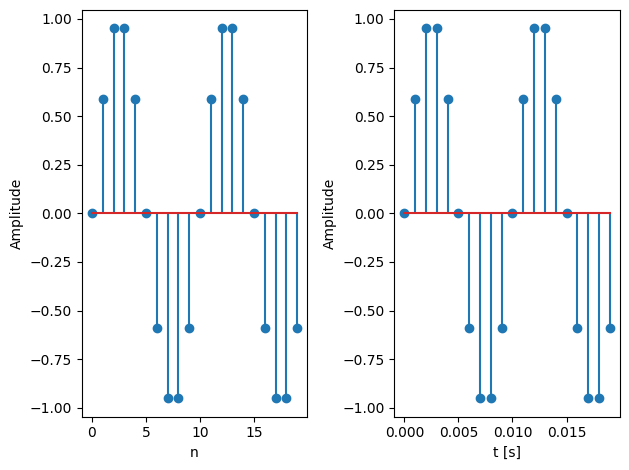

In [2]:
N = 20
r = 1000 # Abtastrate in Hertz
T = 1/r # Abtastdauer in Sekunden
FrequencyInHertz = 100

n_axis = np.arange(N)
PhysicalTimestamps = n_axis * T
SignalTimeDomain = np.sin(2*np.pi*FrequencyInHertz*PhysicalTimestamps)

plt.subplot(1,2,1)
plt.stem(n_axis, SignalTimeDomain)
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.subplot(1,2,2)
plt.stem(PhysicalTimestamps, SignalTimeDomain)
plt.xlabel('t [s]')
plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()

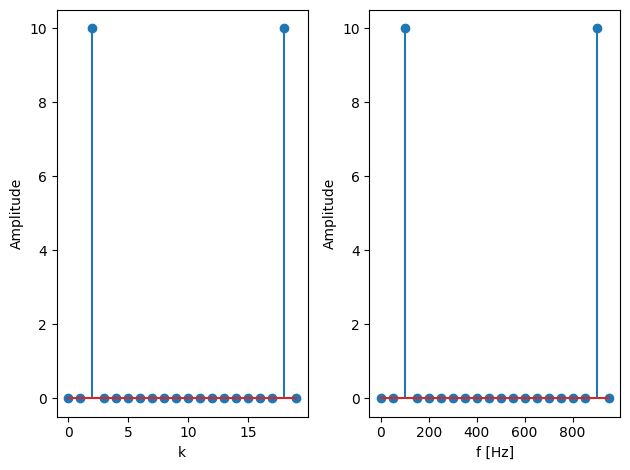

In [3]:
K = N

SignalFrequencyDomain = np.fft.fft(SignalTimeDomain, K)

Delta_f = 1 / (T*K)
k_axis = np.arange(K)
PhysicalFrequencies = k_axis * Delta_f

plt.subplot(1,2,1)
plt.stem(k_axis, np.abs(SignalFrequencyDomain))
plt.xlabel('k')
plt.ylabel('Amplitude')
plt.subplot(1,2,2)
plt.stem(PhysicalFrequencies, np.abs(SignalFrequencyDomain))
plt.xlabel('f [Hz]')
plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()

## Hörbarmachung der DFT
Im Folgenden wird ein einfaches Signal angenommen: ein einfrequenter Sinus. Das zugehörige DFT-Ergebnis wird als Spektrum dargestellt. Zusätzlich wird das Signal als Wave-Datei gespeichert, um in Hörversuchen zu prüfen, ob die festgelegte Frequenz korrekt in die Wave-Datei übernommen wurde.

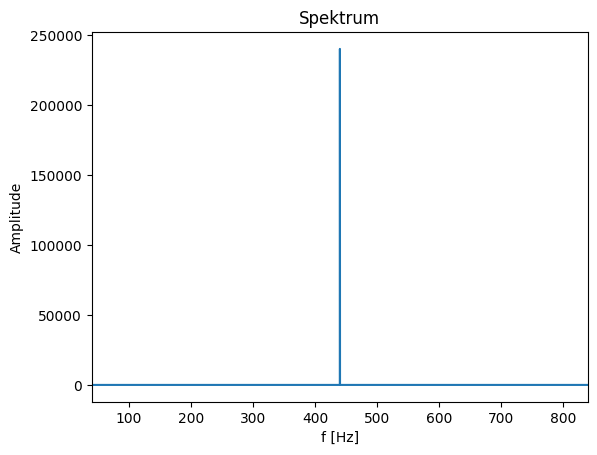

In [4]:
r = 48000
Frequency = 440 # Frequenz in Hertz
DurationInSeconds = 10
t = np.arange(DurationInSeconds*r)/r
x = np.sin(2*np.pi*Frequency*t)
K = x.shape[0]
Delta_f = r / K
X = np.abs(np.fft.fft(x, K))
f = np.arange(X.shape[0]) * Delta_f
plt.plot(f, X)
plt.xlim(Frequency-400, Frequency+400)
plt.xlabel('f [Hz]')
plt.ylabel('Amplitude')
plt.title('Spektrum')
plt.show()

WaveFileHandling.WriteWaveAsNumpyArray(x, r, 'sinus.wav')

## Zero Padding

Die DFT-Gleichung wurde oben bereits eingeführt:

$X(k)=\sum_{n=0}^{N-1} x(n)\cdot e^{-j2\pi nk/K}$

mit $0\leq n<N$ und $0\leq k < K$.
$N$ ist die Länge des analysierten Zeitsignals und $K$ ist die sogenannte Transformationslänge.

Die Frequenzauflösung der DFT ergibt sich aus

$\Delta f=\frac{1}{KT}$, wobei $T$ die Abtastdauer bzw. der Kehrwert der Abtastrate $r$ ist.

Die Frequenzauflösung kann durch Vergrößern von $K$ erhöht werden. Falls $K>N$, ergänzt die DFT das Signal $x(n)$ vor der Transformation zu $X(k)$ am Ende um $K-N$ Nullen. Das nennt man Zero Padding. Die erhöhte Frequenzauflösung liefert keine zusätzliche Information über das Spektrum. Stattdessen wird das zugrunde liegende kontinuierliche Spektrum nur feiner abgetastet.

Zero Padding hat zwei Hauptmotive: Erstens kann damit eine gegebene Frequenz gezielter analysiert werden. Zweitens kann eine Transformationslänge $K$ verwendet werden, die eine Zweierpotenz ist. Das beschleunigt die Berechnung der DFT in der Regel, besonders auf leistungsschwächeren Prozessoren.

Um den Effekt von Zero Padding zu zeigen, wird im Folgenden ein Dreieckssignal angenommen (im linken Diagramm schwarz dargestellt):

$x(t)=
\begin{cases}
    1-\left|t\right|,& \text{für } -1\leq t\leq 1\\
    0,              & \text{sonst}
\end{cases}
$

Das zugehörige kontinuierliche Spektrum kann über die Fourier-Transformation bestimmt werden:

$X(f)=\int_{-\infty}^\infty x(t)\cdot e^{-j2\pi ft}dt=\text{sinc}^2(f)$

Es ist im rechten Diagramm als schwarze gestrichelte Linie eingezeichnet.

Das Ergebnis der DFT ohne Zero Padding ist blau dargestellt. Das Ergebnis der DFT mit Zero Padding und $K=3\cdot N$ ist rot dargestellt. Durch den Faktor $\frac{K}{N}=3$ werden dreimal so viele Frequenzen durch die DFT ausgewertet. Diese zusätzlichen Frequenzen enthalten jedoch keine neue Information, da das zugrunde liegende kontinuierliche Spektrum (schwarze gestrichelte Linie) nur genauer abgetastet wird.

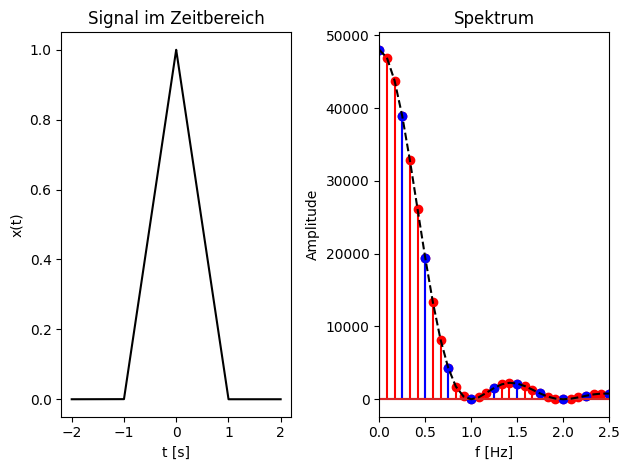

In [5]:
r = 48000
T = 1/r
t = np.arange(4*r)/(r) - 2 # vier Sekunden
x = np.maximum(1 - np.abs(t), 0.0)

def EvaluateSpectrum(x, K, r):
    X = np.fft.fft(x, K)
    NyquistIndex = int(K/2+1)
    X = np.abs(X[0:NyquistIndex])
    Deltaf = r/K
    f = np.arange(NyquistIndex) * Deltaf
    return X, f

N = x.shape[0]
X, f = EvaluateSpectrum(x, N, r)

K = 3*N
X_zeropadded, f_zeropadded = EvaluateSpectrum(x, K, r)

plt.subplot(1,2,1)
plt.plot(t, x, 'k')
plt.xlabel('t [s]')
plt.ylabel('x(t)')
plt.title('Signal im Zeitbereich')

plt.subplot(1,2,2)
plt.stem(f_zeropadded, X_zeropadded, 'r')
plt.stem(f, X, 'b')
plt.plot(f_zeropadded, (np.sinc(f_zeropadded)**2)*X[0], '--k') # das wahre Spektrum
plt.xlim(0, 2.5)
plt.xlabel('f [Hz]')
plt.ylabel('Amplitude')
plt.title('Spektrum')

plt.tight_layout()
plt.show()

## Symmetrie
Wenn die Eingangsdaten reellwertig sind, ist das Ausgangsspektrum bezüglich der halben Abtastfrequenz symmetrisch:

$X(k) = X^*(K-k)$

Zur Reduktion des Speicherbedarfs wird der zweite symmetrische Teil des Spektrums bei der weiteren Analyse üblicherweise verworfen, da er redundant ist.
Der höchste Index, der für die Analyse behalten werden muss, ist der Index der Nyquist-Frequenz: $f_\text{Nyquist} = \frac{r}{2}$.

Der nullte Index entspricht der Frequenz $f=0$ Hz, also dem Gleichanteil (DC-Anteil) des Signals. Für gerade Werte von $K$ ist das Element an der Nyquist-Frequenz aufgrund der Symmetriebedingung an diesem Punkt rein reell:

$X\left(k_\text{Nyquist}\right)=X^*\left(k_\text{Nyquist}\right)$

In [6]:
N = np.random.randint(1000)
K = int(2**np.ceil(np.log2(N)))

x = np.random.randn(N)
X = np.fft.fft(x, K)

for k in range(1, K):
    assert np.abs(X[k] - np.conj(X[K-k])) < 1e-10, 'Fehler in der DFT-Symmetrie'
    
NyquistIndex = K // 2 + 1
X_FirstHalfOfSpectrum = X[0:NyquistIndex]
Y = np.zeros((K), dtype = complex)
for k in range(K):
    if k < X_FirstHalfOfSpectrum.shape[0]:
        Y[k] = X_FirstHalfOfSpectrum[k]
    else:
        Y[k] = np.conj(Y[K- k])
assert np.sum(np.abs(X - Y)) < 1e-6, 'falsche Rekonstruktion des zweiten symmetrischen Teils des Spektrums'

## Parseval-Theorem
Das Parseval-Theorem für kontinuierliche Signale besagt, dass die Energie im Zeitbereich $x(t)$ oder im Frequenzbereich $X(f)$ bestimmt werden kann:

$E=\int_{-\infty}^\infty x(t) dt = \int_{-\infty}^\infty X(f) df$

Das gilt auch für die DFT, mit einem Skalierungsfaktor $\frac{1}{K}$:

$E=\sum_{n=0}^{N-1} \left|x(n)\right|^2=\frac{1}{K}\sum_{k=0}^{K-1}\left|X(k)\right|^2$

Bei geraden Werten von $K$ kann das Parseval-Theorem für die erste Spektrumshälfte nicht exakt erfüllt werden: An der Nyquist-Frequenz geht der Imaginärteil verloren. Daher ist das Parseval-Theorem in diesem Fall für gerade $K$ nicht exakt erfüllt.

In [7]:
N = np.random.randint(1000)
K = N + np.random.randint(1000)

x = np.random.randn(N)
X = np.fft.fft(x, K)

# Parseval-Theorem für das vollständige Spektrum
E_x = np.sum(np.abs(x)**2)
E_X = np.sum(np.abs(X)**2) / K
assert np.abs(E_x - E_X)< 1e-10, 'Fehler bei der Auswertung des Parseval-Theorems'

# Parseval-Theorem für die relevante erste Spektrumshälfte
NyquistIndex = K // 2 + 1
X_FirstHalfOfSpectrum = X[0:NyquistIndex]
X2_FirstHalfOfSpectrum = np.abs(X_FirstHalfOfSpectrum)**2
X2_FirstHalfOfSpectrum[1:] *= 2
E_X = np.sum(X2_FirstHalfOfSpectrum) / K
if (K % 2) == 1:
    assert np.abs(E_X - E_x) < 1e-10, 'Fehler bei der Auswertung des Parseval-Theorems für die erste Spektrumshälfte'

## Periodizität
Die DFT bzw. FFT setzt ein periodisches Signal voraus. Diese Periodizitätsannahme führt zu Problemen, wenn das zu analysierende Signal keine vollständige Periode enthält, also wenn $N$ kein ganzzahliges Vielfaches der Periodenlänge ist. In diesem Fall passen Anfang und Ende des Blocks der Länge $N$ nicht zusammen. Dieses Verhalten wird durch zwei Signale $x(n)$ und $y(n)$ veranschaulicht: $x(n)$ enthält eine vollständige Periode (oder eine ganze Anzahl von Perioden), $y(n)$ hingegen nicht. Das Spektrum von $y(n)$ ist rot dargestellt und enthält neben dem Maximum bei 10 Hz eine große Energiemenge. Diese zusätzliche Energie neben dem Maximum nennt man Frequenzverschmierung bzw. Leakage der DFT.

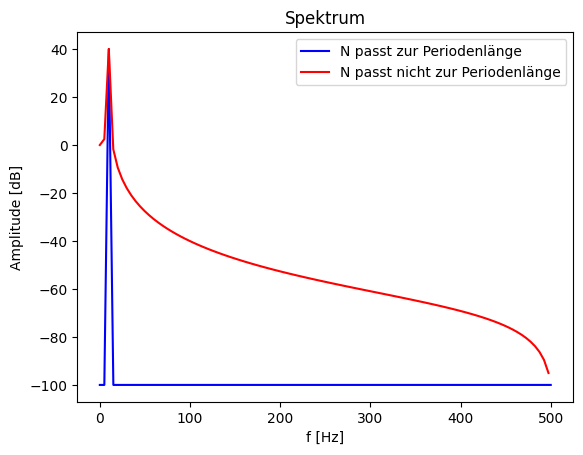

In [8]:
def EvaluateSpectrum(x, Fs):
    X = np.fft.fft(x)
    NyquistIndex = int(X.shape[0]/2+1)
    X = np.abs(X[0:NyquistIndex])
    f = np.arange(X.shape[0])/x.shape[0]*Fs
    X_level = 20*np.log10(X + 1e-5)
    return X_level, f

Fs = 1000
f = 10
n = np.arange(int(2*Fs/f))
x = np.cos(2*np.pi*f*n/Fs)
n = np.arange(int(2*Fs/f+1))
y = np.cos(2*np.pi*f*n/Fs)

X, f_x = EvaluateSpectrum(x, Fs)
Y, f_y = EvaluateSpectrum(y, Fs)

plt.plot(f_x, X, 'b')
plt.plot(f_y, Y, 'r')
plt.xlabel('f [Hz]')
plt.ylabel('Amplitude [dB]')
plt.title('Spektrum')
plt.legend(['N passt zur Periodenlänge', 'N passt nicht zur Periodenlänge'])
plt.show()

## Fensterfunktion
Ein gängiger Workaround für die DFT-Annahme periodischer Eingangssignale ist die Verwendung einer Fensterfunktion $w(n)$, die elementweise mit dem zu analysierenden Signal $x(n)$ multipliziert wird. Diese Fensterfunktionen realisieren ein Ein- und Ausblenden des Signals $x(n)$. Eine häufig verwendete Fensterfunktion ist das Hann-Fenster:

$w(n) = \frac{1}{2}\left(1-\cos\left(2\pi \frac{n + 0.5}{N}\right)\right)$

Es gibt viele verschiedene Fensterfunktionen. Die meisten besitzen ein eindeutiges Maximum in der Mitte und blenden zum linken und rechten Rand des Fensters aus.

Daher wirken diese Fensterfunktionen im Frequenzbereich wie Tiefpässe.

Im Folgenden wird der Effekt der Fensterfunktion auf die DFT gezeigt:

Das obere Diagramm zeigt den Zeitbereich. Das nichtperiodische Signal $y(n)$ ist rot dargestellt. Das Ergebnis der Multiplikation mit dem Hann-Fenster ist schwarz dargestellt:

$y_\text{windowed}(n)=y(n)\cdot w(n)$

Das obere Diagramm zeigt das Ein- und Ausblenden durch die Multiplikation mit dem Hann-Fenster.

Das untere Diagramm zeigt die DFT des periodischen Signals $x(n)$ in Blau als Referenz. Die DFT des nichtperiodischen Signals $y(n)$ ist erneut in Rot dargestellt. Zusätzlich ist die DFT des gefensterten Signals $y_\text{windowed}(n)$ dargestellt.

Im unteren Diagramm wird der Einfluss der Hann-Fensterung im Frequenzbereich sichtbar: Die Verschmierung wird deutlich reduziert.

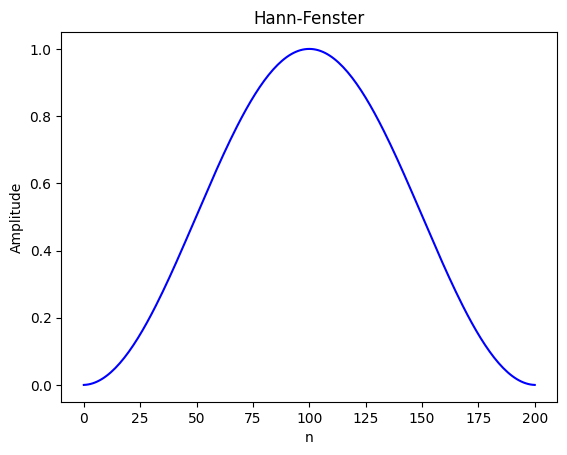

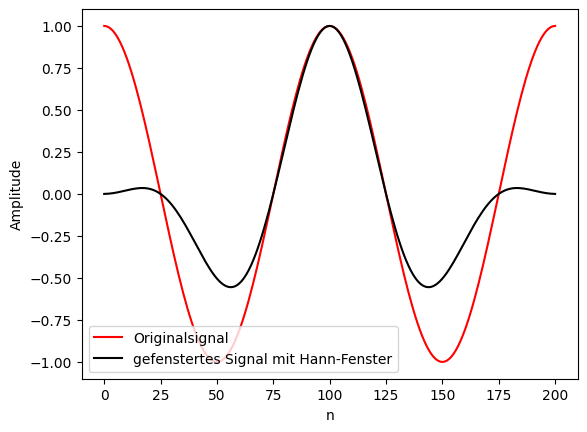

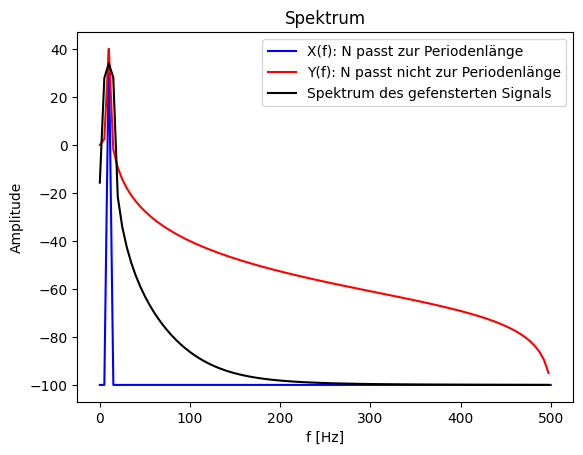

In [9]:
def HannWindow(N):
    n = np.arange(N)
    return 0.5 * (1 - np.cos(2*np.pi*(n+0.5)/N))

w = HannWindow(y.shape[0])
y_windowed = y * w

plt.plot(n, w, 'b')
plt.title('Hann-Fenster')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.show()

plt.plot(n, y, 'r')
plt.plot(n, y_windowed, 'k')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.legend(['Originalsignal', 'gefenstertes Signal mit Hann-Fenster'])
plt.show()

Y_windowed, f_y = EvaluateSpectrum(y_windowed, Fs)

plt.plot(f_x, X, 'b')
plt.plot(f_y, Y, 'r')
plt.plot(f_y, Y_windowed, 'k')
plt.xlabel('f [Hz]')
plt.ylabel('Amplitude')
plt.title('Spektrum')
plt.legend(['X(f): N passt zur Periodenlänge', 'Y(f): N passt nicht zur Periodenlänge', 'Spektrum des gefensterten Signals'])
plt.show()

## Programmieraufgabe:

Der DFT-Algorithmus kann als Matrixmultiplikation beschrieben werden:

$X(k)=\sum_{n=0}^{N-1} x(n)\cdot e^{-j2\pi nk/K}, 0\leq n<N$

$\rightarrow X=T_\text{DFT}\cdot x$

1) Bestimme die Transformationsmatrix $T_\text{DFT}$ in der Prozedur DFTByMatrixMultiplication.
2) Implementiere die Option Zero Padding ($K > N$) in der Prozedur DFTByMatrixMultiplication.
3) Die Multiplikation mit der Fensterfunktion HannWindow(N) kann ebenfalls als Matrixmultiplikation beschrieben werden. Implementiere die entsprechende Prozedur WindowingByMatrixMultiplication.
4) Beide Operationen, Fensterung und DFT, können in einer einzigen Matrixmultiplikation kombiniert werden.

In [10]:
def DFTByMatrixMultiplication(N, K = None):  # Erzeugt die DFT-Transformationsmatrix T mit Form (K x N)
    if K is None:  # Falls kein K gegeben ist, nutzen wir den Standardfall ohne Zero-Padding
        K = N  # Setzt Transformationslaenge gleich Signallaenge
    assert K >= N, 'K muss fuer Zero Padding groesser oder gleich N sein'  # Zero-Padding ist nur sinnvoll/freigegeben fuer K >= N

    n = np.arange(N)  # Zeitindex-Vektor n = [0, 1, ..., N-1]
    k = np.arange(K)[:, np.newaxis]  # Frequenzindex-Vektor k als Spaltenvektor fuer Broadcasting
    T = np.exp(-1j * 2 * np.pi * k * n / K)  # Matrixelemente T[k,n] = exp(-j*2*pi*n*k/K)
    return T  # Gibt die fertige DFT-Matrix zurueck

def WindowingByMatrixMultiplication(N):  # Erzeugt die Matrix fuer die Fensterung als lineare Abbildung
    w = HannWindow(N)  # Berechnet die N Hann-Fensterkoeffizienten
    T = np.diag(w)  # Baut eine Diagonalmatrix, sodass T @ x genau x * w ergibt
    return T  # Gibt die Fensterungsmatrix zurueck

def WindowingAndDFTByMatrixMultiplication(N, K = None):  # Kombiniert Fensterung und DFT in einer einzigen Matrix
    T_dft = DFTByMatrixMultiplication(N, K)  # DFT-Matrix (mit optionalem Zero-Padding) erzeugen
    T_window = WindowingByMatrixMultiplication(N)  # Fensterungsmatrix erzeugen
    T = np.matmul(T_dft, T_window)  # Kombinierte Abbildung: erst fenstern, dann DFT
    return T  # Gibt die kombinierte Matrix zurueck

import unittest

class TestProgrammingExercise(unittest.TestCase):

    def test_DFTByMatrixMultiplication(self):
        N = np.random.randint(1000) + 1
        x = np.random.randn(N)
        T = DFTByMatrixMultiplication(N)
        y1 = np.matmul(T, x)
        y2 = np.fft.fft(x)
        self.assertGreater(10*np.log10(np.sum(np.abs(y2)**2)/np.sum(np.abs(y1-y2)**2+1e-16)), 100)

    def test_DFTByMatrixMultiplicationZeroPadding(self):
        N = np.random.randint(1000) + 1
        K = int(2**np.ceil(np.log2(N)))
        x = np.random.randn(N)
        T = DFTByMatrixMultiplication(N, K)
        y1 = np.matmul(T, x)
        y2 = np.fft.fft(x, n = K)
        self.assertGreater(10*np.log10(np.sum(np.abs(y2)**2)/np.sum(np.abs(y1-y2)**2+1e-16)), 100)

    def test_WindowingByMatrixMultiplication(self):
        N = np.random.randint(1000) + 1
        K = N + np.random.randint(10)
        x = np.random.randn(N)
        w = HannWindow(N)
        T = WindowingByMatrixMultiplication(N)
        y1 = np.matmul(T, x)
        y2 = x*w
        self.assertGreater(10*np.log10(np.sum(np.abs(y2)**2)/np.sum(np.abs(y1-y2)**2+1e-16)), 100)

    def test_WindowingAndDFTByMatrixMultiplication(self):
        N = np.random.randint(1000) + 1
        K = N + np.random.randint(10)
        x = np.random.randn(N)
        w = HannWindow(N)
        T = WindowingAndDFTByMatrixMultiplication(N)
        y1 = np.matmul(T, x)
        y2 = np.fft.fft(x*w)
        self.assertGreater(10*np.log10(np.sum(np.abs(y2)**2)/np.sum(np.abs(y1-y2)**2+1e-16)), 100)
    
unittest.main(argv=[''], verbosity=2, exit=False)

test_DFTByMatrixMultiplication (__main__.TestProgrammingExercise.test_DFTByMatrixMultiplication) ... ok
test_DFTByMatrixMultiplicationZeroPadding (__main__.TestProgrammingExercise.test_DFTByMatrixMultiplicationZeroPadding) ... ok
test_WindowingAndDFTByMatrixMultiplication (__main__.TestProgrammingExercise.test_WindowingAndDFTByMatrixMultiplication) ... ok
test_WindowingByMatrixMultiplication (__main__.TestProgrammingExercise.test_WindowingByMatrixMultiplication) ... ok

----------------------------------------------------------------------
Ran 4 tests in 0.060s

OK


## Prüfungsvorbereitung
1) Beweise die Symmetrie der DFT: $X(k) = X^*(K-k)$.

2) Ein Sinus mit $f=440$ Hz und Amplitude $\hat x = 1$ wird mit einer Abtastrate von $r=1$ kHz abgetastet. Bestimme die ersten drei Abtastwerte $x(n)$. Bestimme das Ergebnis der DFT über diese drei Abtastwerte mit $N=K=3$. Bestimme die Energie im Zeitbereich und im Frequenzbereich.

3) Ein Signal hat die Abtastrate $r=48$ kHz. Die DFT verwendet eine Blocklänge von $N=1000$ und eine Transformationslänge von $K=1024$. Bestimme die Frequenzauflösung $\Delta f$. Wird Zero Padding verwendet? Welcher Index $k$ entspricht $f=50$ Hz? Wie viele Indizes können nach der Transformation aufgrund der Symmetrie verworfen werden?

4) Gib eine Liste von Vor- und Nachteilen der DFT an.

5) Die z-Transformation kann zur Berechnung der Fourier-Transformation eines zeitdiskreten Signals mit folgender Ersetzung verwendet werden: $z\leftarrow e^{j2\pi f/r}$: $X(f)=\sum_{n=-\infty}^\infty x(n)\cdot e^{-j2\pi fn/r}$. Unter welchen Bedingungen ist die Ausgabe der DFT $X(k)=\sum_{n=0}^{N-1}x(n)\cdot e^{-j2\pi nk/N}$ identisch mit der Fourier-Transformation eines zeitdiskreten Signals?

## Prüfungsvorbereitung - Lösungen

### 1) Symmetrie der DFT beweisen
Für ein reelles Signal $x(n) \in \mathbb{R}$ gilt:

$$
X(k)=\sum_{n=0}^{K-1} x(n)e^{-j2\pi nk/K}
$$

Dann ist

$$
X^*(K-k)
=\left(\sum_{n=0}^{K-1} x(n)e^{-j2\pi n(K-k)/K}\right)^*
$$

$$
=\sum_{n=0}^{K-1} x(n)e^{+j2\pi n(K-k)/K}
=\sum_{n=0}^{K-1} x(n)e^{j2\pi n}e^{-j2\pi nk/K}
$$

Da $e^{j2\pi n}=1$ für ganzzahliges $n$:

$$
X^*(K-k)=\sum_{n=0}^{K-1} x(n)e^{-j2\pi nk/K}=X(k)
$$

Also gilt für reelle Signale:

$$
\boxed{X(k)=X^*(K-k)}
$$

### 2) Sinus: $f=440$ Hz, $\hat x=1$, $r=1000$ Hz, $N=K=3$

Signal:

$$
x(n)=\sin\left(2\pi\frac{440}{1000}n\right)=\sin(0.88\pi n)
$$

Erste drei Samples:

- $x(0)=0$
- $x(1)\approx 0.3681246$
- $x(2)\approx -0.6845471$

DFT mit $K=3$:

$$
X(k)=\sum_{n=0}^{2}x(n)e^{-j2\pi nk/3}
$$

Ergebnis:

- $X(0)\approx -0.3164226$
- $X(1)\approx 0.1582113 - j\,0.9116404$
- $X(2)\approx 0.1582113 + j\,0.9116404$

Energie im Zeitbereich:

$$
E_t=\sum_{n=0}^{2}|x(n)|^2\approx 0.60412
$$

Energie im Frequenzbereich (Parseval):

$$
E_f=\frac{1}{K}\sum_{k=0}^{2}|X(k)|^2
=\frac{1}{3}\sum_{k=0}^{2}|X(k)|^2
\approx 0.60412
$$

Damit ist $E_t\approx E_f$.

### 3) $r=48$ kHz, $N=1000$, $K=1024$

Frequenzauflösung:

$$
\Delta f=\frac{r}{K}=\frac{48000}{1024}=46.875\,\text{Hz}
$$

- Zero Padding: Ja, weil $K>N$ (es werden $24$ Nullen angehängt).
- Index für $f=50$ Hz:

$$
k=\frac{f}{\Delta f}=\frac{50}{46.875}\approx 1.067
$$

Also liegt 50 Hz zwischen Bin $k=1$ und $k=2$; nächster Bin ist $k=1$.

- Anzahl verwerfbarer Indizes wegen Symmetrie (reelles Signal):
  Behalten wird bis Nyquist: $K/2+1=513$ Bins.
  Verwerfbar: $1024-513=511$ Bins.

### 4) Vorteile und Nachteile der DFT

Vorteile:
- Spektralanalyse diskreter Signale klar und standardisiert.
- Mit FFT sehr effizient berechenbar.
- Parseval-Zusammenhang für Energie nutzbar.
- Gut kombinierbar mit Fensterung und Zero Padding.

Nachteile:
- Leckeffekte bei nicht periodenkonsistenten Signalsegmenten.
- Begrenzte Frequenzauflösung durch $\Delta f=r/K$.
- Frequenzen zwischen Bins werden nur angenähert dargestellt.
- DFT ohne FFT ist rechenintensiv.

### 5) Wann ist DFT identisch zur Fourier-Transformierten?
Die DFT-Werte sind Abtastungen der DTFT bei

$$
\omega_k=\frac{2\pi k}{N}\quad\Leftrightarrow\quad f_k=\frac{k\,r}{N}
$$

Identisch zur Fourier-Transformierten des betrachteten zeitdiskreten Signals ist die DFT, wenn:
- das Signal im betrachteten Intervall $0\ldots N-1$ vollständig enthalten ist (außerhalb davon 0), oder
- das Signal $N$-periodisch ist und periodenkonsistent analysiert wird.

Andernfalls analysiert die DFT die periodisch fortgesetzte/gefensterte Version des Signals, wodurch z. B. Leckeffekte entstehen können.

## Zusammenfassung
Nach der Bearbeitung dieses Jupyter-Notebooks solltest du die folgenden Fragen beantworten können:

- Was ist der Unterschied zwischen Fourier-Transformation, diskreter Fourier-Transformation und Fast Fourier Transform?

- Welche Bedeutung haben die diskreten Indizes $n$ und $k$ und wie ist der Zusammenhang zu den physikalischen Größen Zeit $t$ und Frequenz $f$?

- Was ist die Motivation für Zero Padding?

- Welchen Effekt hat Zero Padding auf das DFT-Ergebnis $X(k)$?

- Warum wird die zweite Hälfte des Spektrums $X(k)$ in Signalverarbeitungsalgorithmen typischerweise ignoriert?

- Warum verwendet man Fensterfunktionen, z. B. das Hann-Fenster?

## Zusammenfassung - verständlich erklärt

Nach diesem Notebook solltest du die folgenden Punkte sicher erklären können:

### 1) Unterschied zwischen Fourier-Transformation, DFT und FFT
- **Fourier-Transformation (FT):** arbeitet mit kontinuierlicher Zeit bzw. kontinuierlicher Frequenz. Sie beschreibt das ideale mathematische Spektrum eines Signals.
- **Diskrete Fourier-Transformation (DFT):** arbeitet mit endlich vielen diskreten Abtastwerten. Sie liefert Spektralwerte nur an diskreten Frequenzstellen (Bins).
- **Fast Fourier Transform (FFT):** ist **kein anderes Ergebnis**, sondern nur ein sehr effizienter Algorithmus zur Berechnung der DFT.

Merksatz: **FFT berechnet DFT schnell.**

### 2) Bedeutung von $n$ und $k$ sowie Bezug zu $t$ und $f$
- $n$ ist der **Zeitindex** im Abtastwertbereich.
- $k$ ist der **Frequenzindex** im Spektrum.

Mit Abtastrate $r$ und Abtastdauer $T=1/r$ gilt:

$$
t = n\,T
$$

Und für die Frequenzachse der DFT mit Transformationslänge $K$:

$$
\Delta f = \frac{1}{K\,T} = \frac{r}{K},\quad f = k\,\Delta f
$$

Das hast du im Notebook in den Plot-Beispielen mit Achsen in $n/t$ und $k/f$ gesehen.

### 3) Motivation für Zero Padding
Zero Padding bedeutet: Wenn $K>N$, werden hinten Nullen an das Signal angehängt.

Warum macht man das?
- feinere Frequenzabtastung im Spektrum ($\Delta f$ wird kleiner),
- bestimmte Frequenzen können genauer getroffen werden,
- oft günstig für FFT-Implementierungen (z. B. $K$ als Zweierpotenz).

### 4) Effekt von Zero Padding auf $X(k)$
- Das Spektrum wird **dichter abgetastet** (mehr Bins).
- Die Kurve wirkt glatter bzw. genauer interpoliert.
- **Wichtig:** Es entsteht **keine neue physikalische Information** über das Signal.

Genau das zeigte das Notebook mit dem Vergleich ohne und mit Zero Padding beim Dreieckssignal.

### 5) Warum wird die zweite Spektrumshälfte oft ignoriert?
Bei **reellem** Eingangssignal gilt konjugiert-komplexe Symmetrie:

$$
X(k)=X^*(K-k)
$$

Damit steckt in der zweiten Hälfte keine neue Information, sie ist redundant.
Deshalb nutzt man in der Praxis meist nur die erste Hälfte bis zur Nyquist-Frequenz.

### 6) Motivation für Fensterfunktionen (z. B. Hann)
Die DFT nimmt periodische Fortsetzung des betrachteten Blocks an. Wenn Blockanfang und Blockende nicht zusammenpassen, entstehen Sprünge und damit **Leckeffekte** (Verschmierung) im Spektrum.

Fensterung (z. B. Hann) macht ein sanftes Ein- und Ausblenden:
- reduziert Sprünge am Blockrand,
- reduziert Leckeffekte deutlich,
- macht Peaks im Spektrum oft besser interpretierbar.

Nachteil: Auch Fensterung verändert das Spektrum (z. B. Amplituden-/Bandbreiten-Effekte), ist aber in vielen Anwendungen der bessere Kompromiss.